In [1]:
print("Logistic Regression")

Logistic Regression


In [2]:
import pandas as pd 

df = pd.read_csv('diabetes_dataset.csv')

In [3]:
df.head()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
0,69,5,28.39,130.1,77.0,5.4,130.4,44.0,50.0,90.5,107.9,0.84,0,0,0,1,0
1,32,1,26.49,116.5,72.0,4.5,87.4,54.2,129.9,113.3,81.4,1.39,0,0,0,0,0
2,89,13,25.34,101.0,82.0,4.9,112.5,56.8,177.6,84.7,107.2,0.79,0,0,0,1,0
3,78,13,29.91,146.0,104.0,5.7,50.7,39.1,117.0,108.9,110.0,0.99,0,0,0,1,1
4,38,8,24.56,103.2,74.0,4.7,102.5,29.1,145.9,84.1,92.8,0.91,0,1,0,0,0


In [4]:
df.isnull().sum()

Age                   0
Pregnancies           0
BMI                   0
Glucose               0
BloodPressure         0
HbA1c                 0
LDL                   0
HDL                   0
Triglycerides         0
WaistCircumference    0
HipCircumference      0
WHR                   0
FamilyHistory         0
DietType              0
Hypertension          0
MedicationUse         0
Outcome               0
dtype: int64

In [6]:
# Splitting the dataset

from sklearn.model_selection import train_test_split

x = df.drop(columns = ['Outcome'])
y = df['Outcome']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [9]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
from sklearn.linear_model import LogisticRegression

# Training logistic regression model
# model = LogisticRegression()

model = LogisticRegression(penalty = 'l2', C = 0.6 , solver = 'lbfgs')
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.6
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
# Predictions and evulation 

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
import seaborn as sns

y_pred = model.predict(x_test)
print("Diabetes Dataset Accuracy : " , accuracy_score(y_test , y_pred))
print("Confusion Matrix :\n" , confusion_matrix(y_test , y_pred))
print("Classification Report :\n" , classification_report(y_test , y_pred))


Diabetes Dataset Accuracy :  0.9905660377358491
Confusion Matrix :
 [[1274    1]
 [  17  616]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1275
           1       1.00      0.97      0.99       633

    accuracy                           0.99      1908
   macro avg       0.99      0.99      0.99      1908
weighted avg       0.99      0.99      0.99      1908



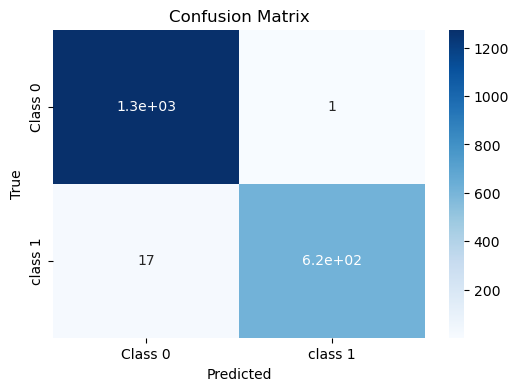

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6,4))
sns.heatmap(conf_mat, annot = True , cmap = 'Blues' , xticklabels =['Class 0' ,'class 1' ], yticklabels = ['Class 0' , 'class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [20]:
import joblib

joblib.dump(model, "logistic_regression_model.joblib")
joblib.dump(scaler, "diabess_scaler.joblib")

['diabess_scaler.joblib']

In [23]:
import numpy as np 
patient_sample = np.array([[69, 5, 28.39, 130.1, 77.0, 5.4, 130.4, 44.0, 50.0, 90.5, 107.9, 0.84, 0, 0, 0, 1]])

loaded_model = joblib.load("logistic_regression_model.joblib")
loaded_scaler = joblib.load("diabess_scaler.joblib")

In [25]:
patient_sample_scaled = loaded_scaler.transform(patient_sample)

predictions = loaded_model.predict(patient_sample_scaled)

d:\Anconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
label_map = {0: "There is no chance of having diabetes", 1 : "There is chance of having diabetes"}

In [27]:
prediction = label_map[predictions[0]]

In [28]:
prediction

'There is no chance of having diabetes'